# From A/B Tests to Bandit Evaluation: Causal Inference for Adaptive Systems

**Author:** Benjamin Weckerle  
**Repository:** github.com/bpw1009/ab-test-bandit-ope  

## Motivation

A/B testing is the gold standard for causal inference in product experimentation. Randomize users into treatment and control, hold conditions fixed, measure the difference. The result is an unbiased estimate of the treatment effect.

But modern personalization systems don't hold conditions fixed. They adapt. A multi-armed bandit continuously shifts traffic toward whichever option appears to be winning. That adaptation is what makes bandits valuable for optimization, and it's exactly what makes them dangerous for learning. The non-random assignment contaminates the causal signal.

This notebook explores that fundamental tension:

- **A/B testing** optimizes for learning at the cost of reward (you serve a worse experience to the control group)
- **Multi-armed bandits** optimize for reward at the cost of learning (you can't easily separate the treatment effect from the selection bias)
- **Off-Policy Evaluation (OPE)** attempts to recover causal answers from bandit logs without running a new experiment

The setting is content personalization on a streaming platform. When a subscriber opens the app, the system chooses which artwork to display on each content tile. The same title can have multiple creative variants: one emphasizing action, another romance, another a familiar actor. The right artwork can mean the difference between a click and a scroll-past, and enough scroll-pasts lead to the worst outcome for the platform: the subscriber decides "nothing looks good," closes the app, and maybe cancels next month.

This is a high-frequency, high-stakes decision that adaptive algorithms make millions of times daily and that can't be individually A/B tested.

---


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.linear_model import LogisticRegression
from typing import Tuple, Dict, List

np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


### The Personalization Problem at a Glance

Before any code, here's the core idea. A streaming platform has one title but multiple artwork variants. Different users respond to different artwork. The system must learn which variant works best for each user type, without showing bad artwork to too many people along the way.


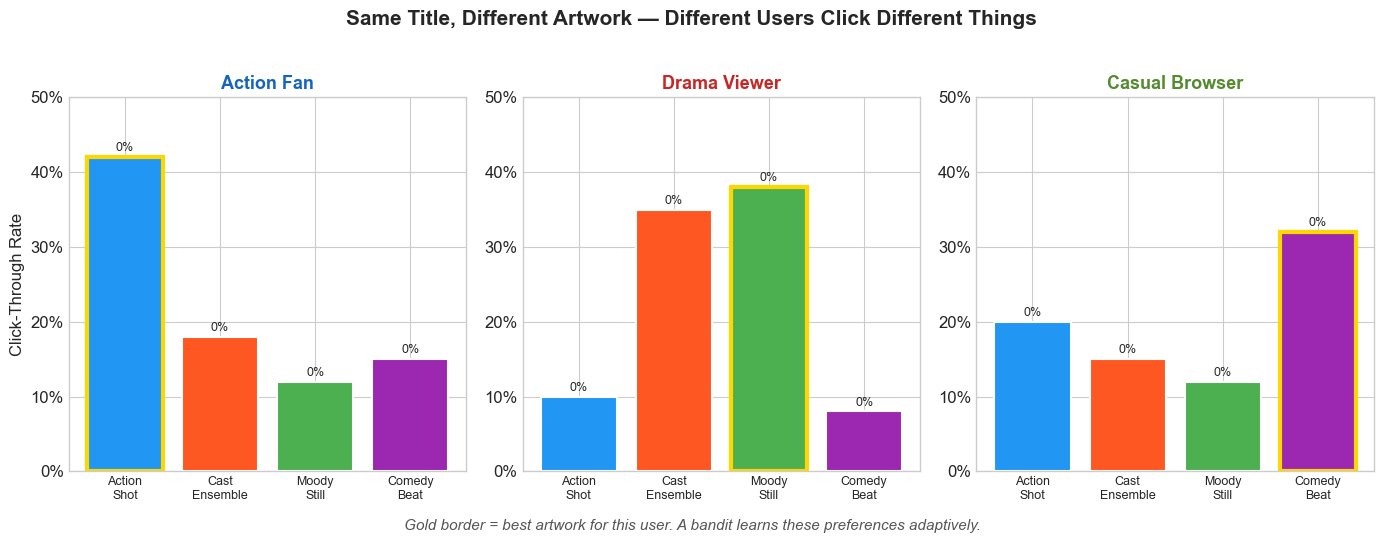

In [2]:
# Conceptual visualization: artwork personalization
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Color palettes for artwork variants
artwork_colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
artwork_labels = ['Action Shot', 'Cast Ensemble', 'Moody Still', 'Comedy Beat']
user_types = ['Action Fan', 'Drama Viewer', 'Casual Browser']
user_colors = ['#1565C0', '#C62828', '#558B2F']

# True CTR matrix (user type x artwork variant)
ctr_matrix = np.array([
    [0.42, 0.18, 0.12, 0.15],  # Action fan
    [0.10, 0.35, 0.38, 0.08],  # Drama viewer
    [0.20, 0.15, 0.12, 0.32],  # Casual browser
])

for idx, (user, color) in enumerate(zip(user_types, user_colors)):
    ax = axes[idx]
    bars = ax.bar(range(4), ctr_matrix[idx], color=artwork_colors, edgecolor='white', linewidth=1.5)
    best = np.argmax(ctr_matrix[idx])
    bars[best].set_edgecolor('#FFD600')
    bars[best].set_linewidth(3)
    ax.set_xticks(range(4))
    ax.set_xticklabels(['Action\nShot', 'Cast\nEnsemble', 'Moody\nStill', 'Comedy\nBeat'], fontsize=9)
    ax.set_ylim(0, 0.50)
    ax.set_ylabel('Click-Through Rate' if idx == 0 else '')
    ax.set_title(f'{user}', fontsize=13, fontweight='bold', color=color)
    ax.bar_label(bars, fmt='%.0f%%', label_type='edge', padding=2, fontsize=9)
    # Format y-axis as percentage
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y*100)}%'))

fig.suptitle('Same Title, Different Artwork — Different Users Click Different Things', 
             fontsize=15, fontweight='bold', y=1.02)
fig.text(0.5, -0.02, 'Gold border = best artwork for this user. A bandit learns these preferences adaptively.', 
         ha='center', fontsize=11, style='italic', color='#555555')
plt.tight_layout()
plt.show()


---

## 1. Simulation Environment: Content Personalization

We simulate a streaming platform that must decide which artwork variant to display for a content tile. There are `K` artwork variants per title (e.g., an action-focused hero shot, a cast ensemble, a moody atmospheric still) and users arrive with contextual features like genre preferences, viewing history, and device type.

Each user-artwork combination has a true click probability that depends on the interaction between user context and artwork characteristics. The platform's goal is to match the right artwork to each user to maximize engagement and prevent browse abandonment: the subscriber who scrolls, decides nothing looks interesting, and closes the app.

Because we control the simulation, we know ground truth. This lets us validate our estimators against actual policy values, something impossible in production.


In [3]:
class ContentPersonalizationEnv:
    """
    Simulates a streaming content personalization scenario.
    
    Users have contextual features (genre preference, browse intensity, device).
    Each artwork variant has a true click-through rate that varies by user context.
    """
    
    def __init__(self, n_arms: int = 4, n_user_features: int = 3, seed: int = 42):
        self.n_arms = n_arms
        self.n_user_features = n_user_features
        self.rng = np.random.RandomState(seed)
        
        # True weight matrix: how each arm responds to each user feature
        # Shape: (n_arms, n_user_features)
        # These are the ground truth parameters we're trying to learn about
        self.arm_weights = self.rng.randn(n_arms, n_user_features) * 0.5
        
        # Arm-specific intercepts (base click rate per artwork)
        self.arm_intercepts = self.rng.uniform(-0.5, 0.5, size=n_arms)
        
    def _sigmoid(self, x: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-np.clip(x, -10, 10)))
    
    def get_true_probs(self, context: np.ndarray) -> np.ndarray:
        """
        Returns the true click probability for each arm given a user context.
        
        Parameters
        ----------
        context : array of shape (n_user_features,)
            User's contextual features
            
        Returns
        -------
        probs : array of shape (n_arms,)
            True click probability for each artwork variant
        """
        logits = self.arm_intercepts + self.arm_weights @ context
        return self._sigmoid(logits)
    
    def generate_users(self, n_users: int) -> np.ndarray:
        """
        Generate user contexts.
        
        Features represent:
        - Feature 0: genre preference score (e.g., action-heavy vs drama-heavy viewer)
        - Feature 1: browse session intensity (how many tiles scrolled past recently)
        - Feature 2: device type score (mobile vs smart TV; artwork impact differs by screen size)
        
        Returns
        -------
        contexts : array of shape (n_users, n_user_features)
        """
        return self.rng.randn(n_users, self.n_user_features)
    
    def pull_arm(self, context: np.ndarray, arm: int) -> int:
        """
        Simulate showing an artwork to a user and observing click/no-click.
        
        Returns
        -------
        reward : 0 or 1
        """
        prob = self.get_true_probs(context)[arm]
        return int(self.rng.random() < prob)
    
    def get_best_arm(self, context: np.ndarray) -> int:
        """Returns the arm with highest true click probability for this context."""
        return int(np.argmax(self.get_true_probs(context)))
    
    def get_policy_value(self, contexts: np.ndarray, policy_fn) -> float:
        """
        Compute the TRUE expected reward of a policy (oracle evaluation).
        
        This is what we're trying to estimate with OPE, but can only compute
        because we control the simulation.
        """
        true_rewards = []
        for ctx in contexts:
            arm = policy_fn(ctx)
            prob = self.get_true_probs(ctx)[arm]
            true_rewards.append(prob)
        return np.mean(true_rewards)


# Initialize environment
env = ContentPersonalizationEnv(n_arms=4, n_user_features=3, seed=42)

# Inspect the environment
print("Arm intercepts (base click rates):")
print(env.arm_intercepts.round(3))
print("\nArm weight matrix (context sensitivity):")
print(env.arm_weights.round(3))

# Show true probabilities for a sample user
sample_user = np.array([0.5, -0.3, 1.0])
probs = env.get_true_probs(sample_user)
print(f"\nSample user context: {sample_user}")
print(f"True click probs per artwork: {probs.round(4)}")
print(f"Best artwork for this user: {np.argmax(probs)}")


Arm intercepts (base click rates):
[-0.196  0.025 -0.068 -0.209]

Arm weight matrix (context sensitivity):
[[ 0.248 -0.069  0.324]
 [ 0.762 -0.117 -0.117]
 [ 0.79   0.384 -0.235]
 [ 0.271 -0.232 -0.233]]

Sample user context: [ 0.5 -0.3  1. ]
True click probs per artwork: [0.5678 0.5802 0.4942 0.4412]
Best artwork for this user: 1


---

## 2. A/B Testing: The Gold Standard for Causal Inference

Before building anything adaptive, we start with the approach every data scientist should understand first: a properly designed randomized experiment.

### 2.1 Experimental Design

We want to test whether Artwork B (our proposed new default) outperforms Artwork A (the current default). Before collecting any data, we specify:

- **Hypothesis:** Artwork B has a higher click-through rate than Artwork A
- **Primary metric:** Click-through rate (CTR)
- **Test type:** Two-sided z-test for proportions
- **Significance level:** 0.05
- **Power:** 0.80

The critical step most A/B testing projects skip is the **power analysis**. How many users do we need before the data is worth analyzing?


True baseline CTR (Artwork A): 0.4527
True treatment CTR (Artwork B): 0.5060
True effect size: +0.0532


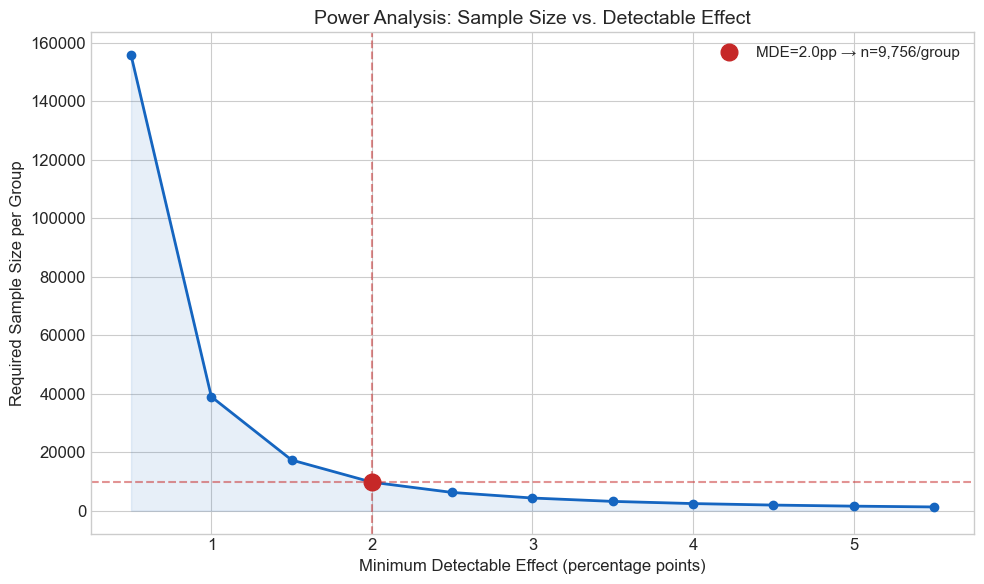


Design decision:
  MDE: 2.0 percentage points
  Required n per group: 9,756
  Total experiment size: 19,512


In [4]:
def power_analysis(
    baseline_ctr: float, 
    mde: float, 
    alpha: float = 0.05, 
    power: float = 0.80
) -> int:
    """
    Compute required sample size per group for a two-proportion z-test.
    """
    p1 = baseline_ctr
    p2 = baseline_ctr + mde
    
    p_pool = (p1 + p2) / 2
    
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    
    numerator = (z_alpha * np.sqrt(2 * p_pool * (1 - p_pool)) + 
                 z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
    denominator = mde ** 2
    
    return int(np.ceil(numerator / denominator))


# Design parameters
test_contexts = env.generate_users(10000)
arm_a, arm_b = 0, 1  # Artwork A (control) vs Artwork B (treatment)

baseline_ctr = np.mean([env.get_true_probs(ctx)[arm_a] for ctx in test_contexts])
treatment_ctr = np.mean([env.get_true_probs(ctx)[arm_b] for ctx in test_contexts])
true_effect = treatment_ctr - baseline_ctr

print(f"True baseline CTR (Artwork A): {baseline_ctr:.4f}")
print(f"True treatment CTR (Artwork B): {treatment_ctr:.4f}")
print(f"True effect size: {true_effect:+.4f}")

# Power analysis for a range of minimum detectable effects
mde_range = np.arange(0.005, 0.06, 0.005)
sample_sizes = [power_analysis(baseline_ctr, mde) for mde in mde_range]

fig, ax = plt.subplots()
ax.plot(mde_range * 100, sample_sizes, 'o-', linewidth=2, color='#1565C0')
ax.fill_between(mde_range * 100, sample_sizes, alpha=0.1, color='#1565C0')
ax.set_xlabel("Minimum Detectable Effect (percentage points)")
ax.set_ylabel("Required Sample Size per Group")
ax.set_title("Power Analysis: Sample Size vs. Detectable Effect")

# Highlight chosen MDE
chosen_idx = 3
ax.axhline(y=sample_sizes[chosen_idx], color='#C62828', linestyle='--', alpha=0.5)
ax.axvline(x=mde_range[chosen_idx] * 100, color='#C62828', linestyle='--', alpha=0.5)
ax.plot(mde_range[chosen_idx] * 100, sample_sizes[chosen_idx], 'o', color='#C62828', 
        markersize=12, zorder=5, label=f"MDE={mde_range[chosen_idx]*100:.1f}pp → n={sample_sizes[chosen_idx]:,}/group")
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# Choose our MDE and compute required n
chosen_mde = 0.02  # 2 percentage points
n_per_group = power_analysis(baseline_ctr, chosen_mde)
print(f"\nDesign decision:")
print(f"  MDE: {chosen_mde*100:.1f} percentage points")
print(f"  Required n per group: {n_per_group:,}")
print(f"  Total experiment size: {n_per_group * 2:,}")


### 2.2 Running the Experiment

With the sample size determined, we randomize users into control (Artwork A) and treatment (Artwork B). The randomization is the entire point: it ensures that any difference in CTR between the groups is attributable to the artwork, not to systematic differences in who saw what.


In [5]:
def run_ab_test(env, n_per_group: int, arm_a: int, arm_b: int, seed: int = 123):
    """Run a properly randomized A/B test."""
    rng = np.random.RandomState(seed)
    total_users = n_per_group * 2
    
    contexts = env.generate_users(total_users)
    
    indices = rng.permutation(total_users)
    control_idx = indices[:n_per_group]
    treatment_idx = indices[n_per_group:]
    
    control_rewards = np.array([env.pull_arm(contexts[i], arm_a) for i in control_idx])
    treatment_rewards = np.array([env.pull_arm(contexts[i], arm_b) for i in treatment_idx])
    
    return {
        'control_rewards': control_rewards,
        'treatment_rewards': treatment_rewards,
        'control_contexts': contexts[control_idx],
        'treatment_contexts': contexts[treatment_idx],
        'control_ctr': control_rewards.mean(),
        'treatment_ctr': treatment_rewards.mean(),
        'observed_effect': treatment_rewards.mean() - control_rewards.mean()
    }


ab_results = run_ab_test(env, n_per_group, arm_a, arm_b)

print(f"Control CTR: {ab_results['control_ctr']:.4f} (n={n_per_group:,})")
print(f"Treatment CTR: {ab_results['treatment_ctr']:.4f} (n={n_per_group:,})")
print(f"Observed effect: {ab_results['observed_effect']:+.4f}")
print(f"True effect: {true_effect:+.4f}")


Control CTR: 0.4598 (n=9,756)
Treatment CTR: 0.5119 (n=9,756)
Observed effect: +0.0521
True effect: +0.0532


### 2.3 Analysis and Inference

With randomized data in hand, the analysis is clean. We test whether the observed difference is statistically significant and compute a confidence interval for the true effect.


In [6]:
def analyze_ab_test(results: dict, alpha: float = 0.05) -> dict:
    """Perform statistical analysis of A/B test results."""
    c = results['control_rewards']
    t = results['treatment_rewards']
    
    n_c, n_t = len(c), len(t)
    p_c, p_t = c.mean(), t.mean()
    
    p_pool = (c.sum() + t.sum()) / (n_c + n_t)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))
    z = (p_t - p_c) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    se_diff = np.sqrt(p_c * (1 - p_c) / n_c + p_t * (1 - p_t) / n_t)
    z_crit = stats.norm.ppf(1 - alpha / 2)
    ci_lower = (p_t - p_c) - z_crit * se_diff
    ci_upper = (p_t - p_c) + z_crit * se_diff
    
    return {
        'z_statistic': z, 'p_value': p_value,
        'ci_lower': ci_lower, 'ci_upper': ci_upper,
        'se': se_diff, 'reject_null': p_value < alpha
    }


analysis = analyze_ab_test(ab_results)

print("=== A/B Test Results ===")
print(f"Z-statistic: {analysis['z_statistic']:.3f}")
print(f"P-value: {analysis['p_value']:.4f}")
print(f"95% CI for effect: [{analysis['ci_lower']:+.4f}, {analysis['ci_upper']:+.4f}]")
print(f"True effect: {true_effect:+.4f}")
print(f"Decision: {'Reject null (significant difference)' if analysis['reject_null'] else 'Fail to reject null'}")


=== A/B Test Results ===
Z-statistic: 7.276
P-value: 0.0000
95% CI for effect: [+0.0381, +0.0661]
True effect: +0.0532
Decision: Reject null (significant difference)


### 2.4 The Cost of Experimentation

The A/B test gave us a clean causal estimate. But it came at a price: we showed Artwork A to half our users even if Artwork B was better. For the duration of the experiment, we sacrificed personalization entirely. Every user got a coin flip, not the best artwork for them.

In a production personalization system running millions of impressions daily, that cost is real and measurable. Each suboptimal artwork impression is a chance for a user to scroll past, and enough scroll-pasts in a session can lead to browse abandonment: the subscriber closes the app without watching anything. At scale, the regret from running a clean experiment translates directly to lost engagement and increased churn risk.


In [7]:
# Quantify the regret
all_contexts = np.vstack([ab_results['control_contexts'], ab_results['treatment_contexts']])
n_total = len(all_contexts)

oracle_rewards = np.array([
    env.get_true_probs(ctx)[env.get_best_arm(ctx)] for ctx in all_contexts
])

ab_expected_rewards = np.concatenate([
    [env.get_true_probs(ctx)[arm_a] for ctx in ab_results['control_contexts']],
    [env.get_true_probs(ctx)[arm_b] for ctx in ab_results['treatment_contexts']]
])

regret = oracle_rewards.mean() - ab_expected_rewards.mean()

print(f"Oracle expected CTR: {oracle_rewards.mean():.4f}")
print(f"A/B test expected CTR: {ab_expected_rewards.mean():.4f}")
print(f"Regret (opportunity cost): {regret:.4f} ({regret/oracle_rewards.mean()*100:.1f}% of oracle)")
print(f"\nOver {n_total:,} impressions, that's ~{int(regret * n_total)} lost clicks")
print(f"At scale (1M daily impressions): ~{int(regret * 1_000_000):,} lost clicks/day during test")


Oracle expected CTR: 0.5823
A/B test expected CTR: 0.4789
Regret (opportunity cost): 0.1035 (17.8% of oracle)

Over 19,512 impressions, that's ~2018 lost clicks
At scale (1M daily impressions): ~103,465 lost clicks/day during test


---

## 3. Multi-Armed Bandits: Optimizing for Reward

A bandit algorithm addresses the cost problem by learning and exploiting simultaneously. Instead of a fixed 50/50 split, it gradually shifts traffic toward the arm that appears to be winning. The tradeoff: better cumulative reward, but the data it generates is no longer randomly assigned.

### 3.1 The Explore-Exploit Tradeoff

We implement an epsilon-greedy contextual bandit. With probability epsilon, it selects a random arm (exploration). Otherwise, it selects the arm with highest predicted reward (exploitation).

The epsilon parameter is the dial that controls everything downstream. Higher epsilon means more exploration: worse short-term performance, but richer data for causal evaluation. Lower epsilon means better exploitation: higher CTR today, but the logged data becomes increasingly useless for evaluating alternative policies.

In production, most systems set epsilon between 0.05 and 0.15. A data scientist would advise on where to set that dial, because they see the downstream effect on evaluation quality.


In [8]:
class EpsilonGreedyContextualBandit:
    """
    Epsilon-greedy contextual bandit using logistic regression per arm.
    
    With probability epsilon, selects a random arm (exploration).
    Otherwise, selects the arm with highest predicted reward (exploitation).
    
    The epsilon parameter is critical for OPE: it guarantees a minimum
    probability of selecting any arm, which is required for importance
    sampling to work.
    """
    
    def __init__(self, n_arms: int, n_features: int, epsilon: float = 0.1, seed: int = 42):
        self.n_arms = n_arms
        self.n_features = n_features
        self.epsilon = epsilon
        self.rng = np.random.RandomState(seed)
        
        self.models = [LogisticRegression(max_iter=1000) for _ in range(n_arms)]
        self.arm_data = {a: {'X': [], 'y': []} for a in range(n_arms)}
        self.is_fitted = [False] * n_arms
        self.min_samples_to_fit = 20
        
    def get_action_probs(self, context: np.ndarray) -> np.ndarray:
        """Returns the probability of selecting each arm. This is the PROPENSITY SCORE."""
        probs = np.full(self.n_arms, self.epsilon / self.n_arms)
        
        if all(self.is_fitted):
            predictions = []
            for a in range(self.n_arms):
                pred = self.models[a].predict_proba(context.reshape(1, -1))[0, 1]
                predictions.append(pred)
            best_arm = np.argmax(predictions)
            probs[best_arm] += (1 - self.epsilon)
        else:
            probs = np.full(self.n_arms, 1.0 / self.n_arms)
            
        return probs
    
    def select_arm(self, context: np.ndarray) -> Tuple[int, float]:
        """Select an arm and return (arm_index, propensity_score)."""
        probs = self.get_action_probs(context)
        arm = self.rng.choice(self.n_arms, p=probs)
        return arm, probs[arm]
    
    def update(self, context: np.ndarray, arm: int, reward: int):
        """Update the model for the pulled arm with observed reward."""
        self.arm_data[arm]['X'].append(context)
        self.arm_data[arm]['y'].append(reward)
        
        if len(self.arm_data[arm]['y']) >= self.min_samples_to_fit:
            X = np.array(self.arm_data[arm]['X'])
            y = np.array(self.arm_data[arm]['y'])
            if len(np.unique(y)) > 1:
                self.models[arm].fit(X, y)
                self.is_fitted[arm] = True


### 3.2 Running the Bandit

We deploy the epsilon-greedy bandit and collect logged interaction data. This logged data is what a production system would generate, and it's what we'll later use for off-policy evaluation.

Notice the key difference from the A/B test: the arm selection is *not random*. The bandit preferentially selects arms it believes are best, creating selection bias in the data. This is what makes naive analysis dangerous.


In [9]:
def run_bandit(env, bandit, n_rounds: int, seed: int = 42) -> pd.DataFrame:
    """Deploy a bandit and collect logged interaction data."""
    rng = np.random.RandomState(seed)
    contexts = env.generate_users(n_rounds)
    
    logs = []
    cumulative_reward = 0
    
    for t in range(n_rounds):
        ctx = contexts[t]
        arm, propensity = bandit.select_arm(ctx)
        reward = env.pull_arm(ctx, arm)
        bandit.update(ctx, arm, reward)
        
        cumulative_reward += reward
        
        log_entry = {
            'round': t, 'arm': arm, 'propensity': propensity,
            'reward': reward, 'cumulative_ctr': cumulative_reward / (t + 1),
        }
        
        for f in range(env.n_user_features):
            log_entry[f'ctx_{f}'] = ctx[f]
        
        true_probs = env.get_true_probs(ctx)
        for a in range(env.n_arms):
            log_entry[f'true_prob_arm_{a}'] = true_probs[a]
        log_entry['best_arm'] = int(np.argmax(true_probs))
        
        logs.append(log_entry)
    
    return pd.DataFrame(logs)


# Run epsilon-greedy bandit
n_rounds = 10000
eg_bandit = EpsilonGreedyContextualBandit(
    n_arms=4, n_features=3, epsilon=0.1, seed=42
)
bandit_logs = run_bandit(env, eg_bandit, n_rounds)

print(f"Bandit data collected: {len(bandit_logs):,} interactions")
print(f"\nArm selection distribution:")
print(bandit_logs['arm'].value_counts().sort_index())
print(f"\nOverall CTR: {bandit_logs['reward'].mean():.4f}")
print(f"\nMean propensity by arm:")
print(bandit_logs.groupby('arm')['propensity'].mean().round(4))


Bandit data collected: 10,000 interactions

Arm selection distribution:
arm
0    2656
1    2152
2    3816
3    1376
Name: count, dtype: int64

Overall CTR: 0.5721

Mean propensity by arm:
arm
0    0.8523
1    0.8335
2    0.8861
3    0.7852
Name: propensity, dtype: float64


### 3.3 A/B Test vs. Bandit vs. Oracle: Cumulative Reward

This is the core tradeoff, made visual. The oracle (which always picks the best arm for each user) sets the ceiling. The A/B test runs flat because it's randomizing. The bandit starts slow while learning, then ramps up as it exploits what it's learned. The area between the curves is the cost of each approach.


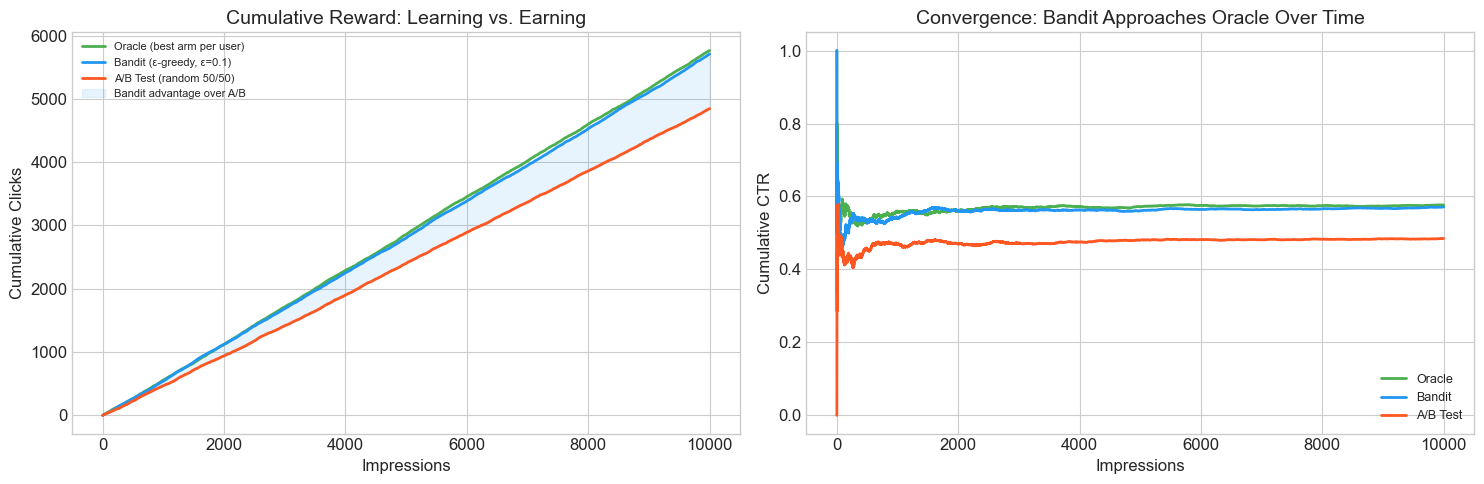

In [10]:
# Generate cumulative reward traces for all three approaches
n_compare = min(n_rounds, len(all_contexts))
compare_contexts = env.generate_users(n_compare)

# Oracle: always picks best arm
oracle_cum = np.cumsum([env.pull_arm(ctx, env.get_best_arm(ctx)) for ctx in compare_contexts])

# A/B test: random 50/50 between arm 0 and arm 1
rng_ab = np.random.RandomState(99)
ab_cum = np.cumsum([
    env.pull_arm(ctx, rng_ab.choice([arm_a, arm_b])) for ctx in compare_contexts
])

# Bandit: run a fresh bandit
bandit_compare = EpsilonGreedyContextualBandit(n_arms=4, n_features=3, epsilon=0.1, seed=99)
bandit_rewards_trace = []
for ctx in compare_contexts:
    arm, _ = bandit_compare.select_arm(ctx)
    reward = env.pull_arm(ctx, arm)
    bandit_compare.update(ctx, arm, reward)
    bandit_rewards_trace.append(reward)
bandit_cum = np.cumsum(bandit_rewards_trace)

rounds = np.arange(1, n_compare + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left: cumulative reward
ax1.plot(rounds, oracle_cum, label='Oracle (best arm per user)', color='#4CAF50', linewidth=2)
ax1.plot(rounds, bandit_cum, label='Bandit (ε-greedy, ε=0.1)', color='#2196F3', linewidth=2)
ax1.plot(rounds, ab_cum, label='A/B Test (random 50/50)', color='#FF5722', linewidth=2)
ax1.fill_between(rounds, ab_cum, bandit_cum, alpha=0.1, color='#2196F3', label='Bandit advantage over A/B')
ax1.set_xlabel("Impressions")
ax1.set_ylabel("Cumulative Clicks")
ax1.set_title("Cumulative Reward: Learning vs. Earning")
ax1.legend(loc='upper left', fontsize=8, framealpha=0.9)

# Right: cumulative CTR (running average)
ax2.plot(rounds, oracle_cum / rounds, label='Oracle', color='#4CAF50', linewidth=2)
ax2.plot(rounds, bandit_cum / rounds, label='Bandit', color='#2196F3', linewidth=2)
ax2.plot(rounds, ab_cum / rounds, label='A/B Test', color='#FF5722', linewidth=2)
ax2.set_xlabel("Impressions")
ax2.set_ylabel("Cumulative CTR")
ax2.set_title("Convergence: Bandit Approaches Oracle Over Time")
ax2.legend(loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()


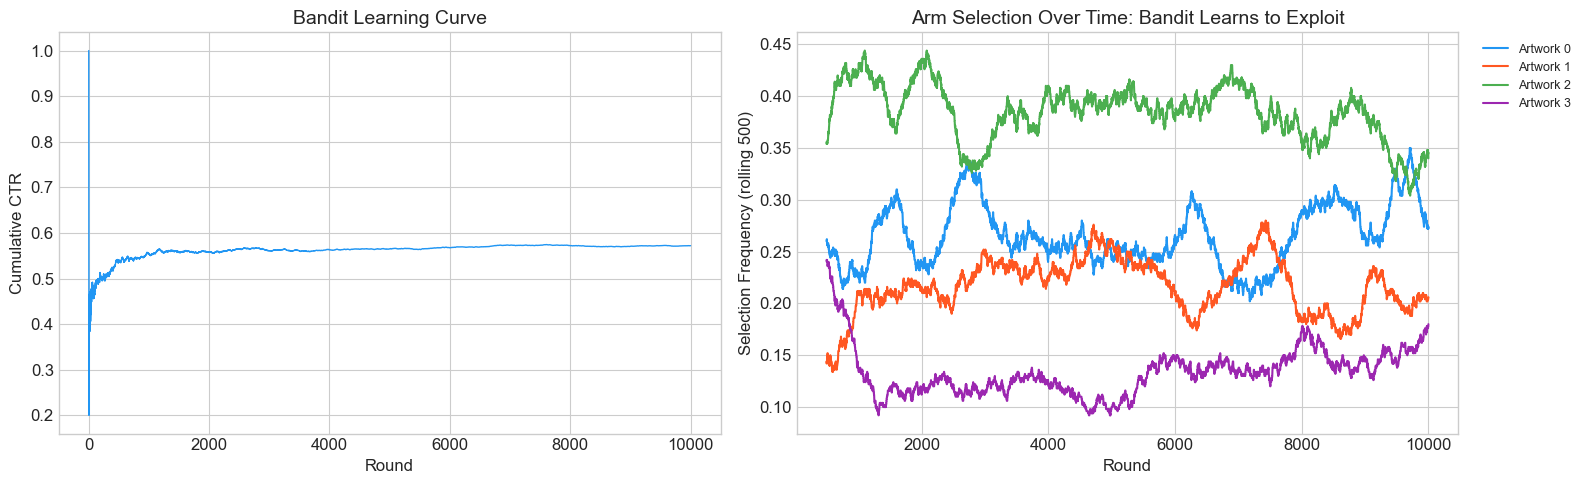

In [11]:
# Bandit learning: arm selection over time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cumulative CTR over time
axes[0].plot(bandit_logs['round'], bandit_logs['cumulative_ctr'], linewidth=1, color='#2196F3')
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Cumulative CTR")
axes[0].set_title("Bandit Learning Curve")

# Arm selection frequency over time (rolling window)
window = 500
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
for arm in range(env.n_arms):
    arm_selected = (bandit_logs['arm'] == arm).astype(float)
    rolling_freq = arm_selected.rolling(window=window).mean()
    axes[1].plot(bandit_logs['round'], rolling_freq, label=f'Artwork {arm}', 
                 linewidth=1.5, color=colors[arm])

axes[1].set_xlabel("Round")
axes[1].set_ylabel(f"Selection Frequency (rolling {window})")
axes[1].set_title("Arm Selection Over Time: Bandit Learns to Exploit")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()


---

## 4. Why Naive Analysis of Bandit Data Fails

Here's where most practitioners make mistakes. If we take the bandit's logged data and compute a simple average reward per arm, we get biased estimates. Why? Because the bandit chose arms based on their perceived quality. Arms that looked good early got pulled more often, and arms that looked bad got starved of data.

This is the same selection bias problem that A/B testing solves through randomization, and the exact problem a data scientist at a streaming platform would need to address.


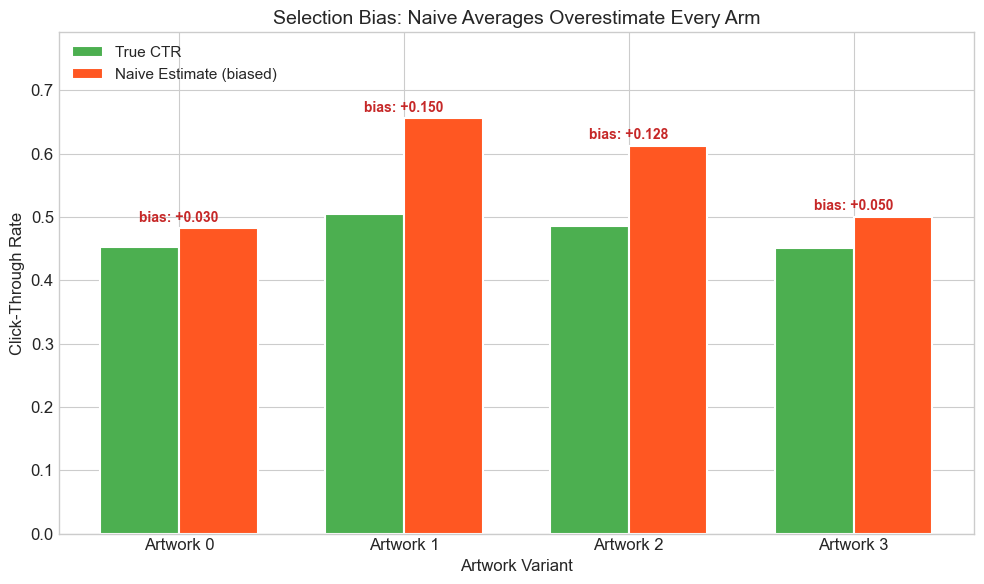

The bandit shows each arm disproportionately to users who are likely to click,
inflating the observed CTR. This is the fundamental problem OPE solves.


In [12]:
# Naive analysis: just average the rewards per arm
naive_estimates = bandit_logs.groupby('arm')['reward'].mean()

# True arm values (averaged over the user population)
eval_contexts = env.generate_users(50000)
true_arm_values = {}
for arm in range(env.n_arms):
    true_arm_values[arm] = np.mean([env.get_true_probs(ctx)[arm] for ctx in eval_contexts])

# Visualization: naive vs true arm values
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(env.n_arms)
width = 0.35

bars_true = ax.bar(x - width/2, [true_arm_values[a] for a in range(env.n_arms)], 
                    width, label='True CTR', color='#4CAF50', edgecolor='white', linewidth=1.5)
bars_naive = ax.bar(x + width/2, [naive_estimates[a] for a in range(env.n_arms)], 
                     width, label='Naive Estimate (biased)', color='#FF5722', edgecolor='white', linewidth=1.5)

# Annotate bias
for a in range(env.n_arms):
    bias = naive_estimates[a] - true_arm_values[a]
    y_pos = max(naive_estimates[a], true_arm_values[a]) + 0.01
    ax.annotate(f'bias: {bias:+.3f}', xy=(a, y_pos), ha='center', fontsize=10,
                fontweight='bold', color='#C62828')

ax.set_xlabel("Artwork Variant")
ax.set_ylabel("Click-Through Rate")
ax.set_title("Selection Bias: Naive Averages Overestimate Every Arm")
ax.set_xticks(x)
ax.set_xticklabels([f'Artwork {a}' for a in range(env.n_arms)])
ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

print("The bandit shows each arm disproportionately to users who are likely to click,")
print("inflating the observed CTR. This is the fundamental problem OPE solves.")


---

## 5. Off-Policy Evaluation: Causal Inference from Bandit Logs

Off-policy evaluation recovers causal estimates from non-experimental data. The key insight: if we know the probability with which the logging policy selected each arm (the propensity score), we can reweight the observations to remove the selection bias.

This is directly analogous to inverse propensity weighting in observational causal inference. The logging policy is like a non-random treatment assignment mechanism, and the propensity score tells us how non-random it was.

### 5.1 Defining a Target Policy

Suppose we've trained a new personalization model and want to estimate how it would perform before deploying it. This is the target policy we want to evaluate using only the logged data from the current (logging) policy.


In [13]:
def target_policy_simple(context: np.ndarray) -> int:
    """
    A simple rule-based target policy.
    Represents a 'new model' someone wants to evaluate before deploying.
    """
    if context[0] > 0.5:
        return 0
    elif context[1] > 0:
        return 2
    else:
        return 1


# Vectorized helper for target arm computation
def get_target_arms(logs: pd.DataFrame, target_policy_fn, n_features: int = 3) -> np.ndarray:
    """Compute target policy arm selections for all logged contexts."""
    contexts = logs[[f'ctx_{f}' for f in range(n_features)]].values
    return np.array([target_policy_fn(ctx) for ctx in contexts])


# True value of the target policy (oracle, for validation)
eval_contexts = env.generate_users(50000)
true_target_value = env.get_policy_value(eval_contexts, target_policy_simple)
print(f"True value of target policy: {true_target_value:.4f}")

for arm in range(env.n_arms):
    val = env.get_policy_value(eval_contexts, lambda ctx, a=arm: a)
    print(f"True value of always-arm-{arm}: {val:.4f}")

oracle_value = env.get_policy_value(eval_contexts, lambda ctx: env.get_best_arm(ctx))
print(f"True value of oracle policy: {oracle_value:.4f}")


True value of target policy: 0.4726
True value of always-arm-0: 0.4522
True value of always-arm-1: 0.5047
True value of always-arm-2: 0.4856
True value of always-arm-3: 0.4499
True value of oracle policy: 0.5819


### 5.2 Inverse Propensity Scoring (IPS)

The most fundamental OPE estimator. For each logged interaction where the logging policy happened to choose the same arm the target policy would have chosen, we reweight the reward by the inverse of the propensity score.

The intuition: if the logging policy rarely chose an arm but the target policy always would, the few observations of that arm are upweighted to compensate.


In [14]:
def ips_estimator(
    logs: pd.DataFrame, target_policy_fn, n_arms: int,
    n_features: int = 3, clip: float = None, target_arms: np.ndarray = None
) -> Dict:
    """Inverse Propensity Scoring estimator (vectorized)."""
    n = len(logs)
    
    if target_arms is None:
        target_arms = get_target_arms(logs, target_policy_fn, n_features)
    
    arms = logs['arm'].values
    propensities = logs['propensity'].values
    rewards = logs['reward'].values
    
    match = (arms == target_arms)
    importance_weights = np.where(match, 1.0 / propensities, 0.0)
    
    if clip is not None:
        importance_weights = np.minimum(importance_weights, clip)
    
    weighted_rewards = importance_weights * rewards
    
    estimate = weighted_rewards.mean()
    se = np.std(weighted_rewards) / np.sqrt(n)
    
    nonzero = importance_weights > 0
    return {
        'estimate': estimate, 'se': se,
        'ci_lower': estimate - 1.96 * se,
        'ci_upper': estimate + 1.96 * se,
        'effective_n': int(np.sum(nonzero)),
        'max_weight': importance_weights.max(),
        'mean_weight': importance_weights[nonzero].mean() if np.any(nonzero) else 0,
        'importance_weights': importance_weights,
    }


# Precompute target arms (reused across estimators)
target_arms = get_target_arms(bandit_logs, target_policy_simple)
ips_result = ips_estimator(bandit_logs, target_policy_simple, env.n_arms, target_arms=target_arms)

print("=== Inverse Propensity Scoring ===")
print(f"Estimate: {ips_result['estimate']:.4f}")
print(f"95% CI: [{ips_result['ci_lower']:.4f}, {ips_result['ci_upper']:.4f}]")
print(f"True value: {true_target_value:.4f}")
print(f"Bias: {ips_result['estimate'] - true_target_value:+.4f}")
print(f"Effective n: {ips_result['effective_n']:,} / {len(bandit_logs):,}")
print(f"Max importance weight: {ips_result['max_weight']:.1f}")


=== Inverse Propensity Scoring ===
Estimate: 0.5234
95% CI: [0.4496, 0.5971]
True value: 0.4726
Bias: +0.0508
Effective n: 2,916 / 10,000
Max importance weight: 40.0


### Why IPS Has High Variance

The importance weight distribution tells the story. Most observations have weight 0 (the logging policy chose a different arm than the target policy would have). Among the matched observations, a few have extreme weights because the logging policy assigned very low probability to the arm the target wanted. These extreme weights dominate the estimate and create variance.


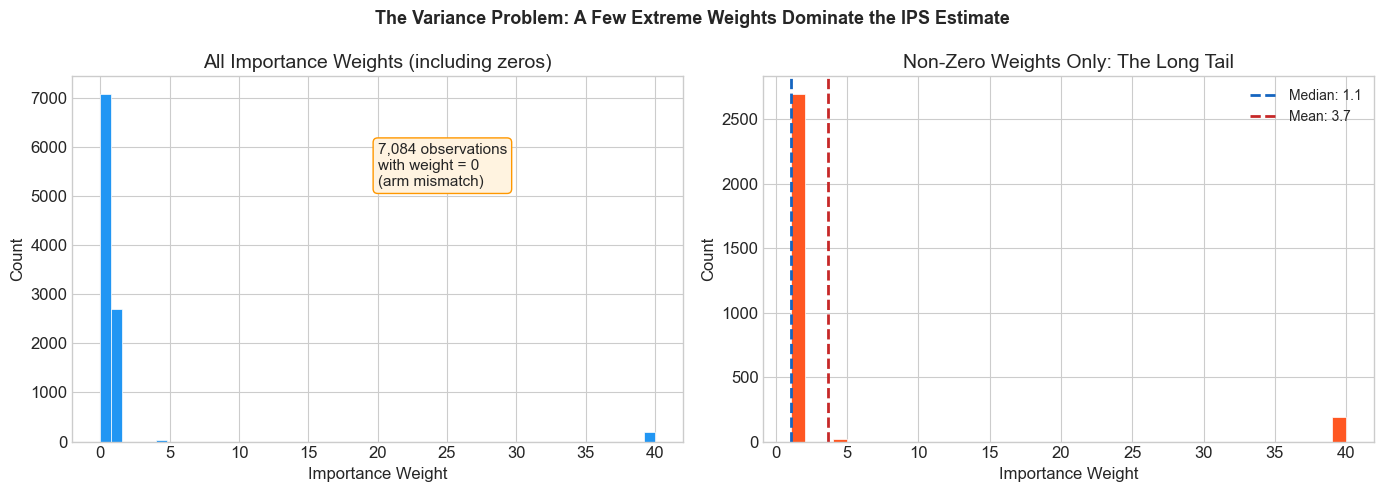

Weight statistics (non-zero only):
  Median: 1.08
  Mean:   3.68
  Max:    40.00
  Std:    9.67


In [15]:
# Importance weight distribution
iw = ips_result['importance_weights']
iw_nonzero = iw[iw > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution including zeros
ax = axes[0]
ax.hist(iw, bins=50, color='#2196F3', edgecolor='white', linewidth=0.5)
ax.set_xlabel("Importance Weight")
ax.set_ylabel("Count")
ax.set_title("All Importance Weights (including zeros)")
ax.annotate(f'{np.sum(iw == 0):,} observations\nwith weight = 0\n(arm mismatch)', 
            xy=(0.5, 0.7), xycoords='axes fraction', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0', edgecolor='#FF9800'))

# Right: non-zero weights only (log scale)
ax = axes[1]
ax.hist(iw_nonzero, bins=40, color='#FF5722', edgecolor='white', linewidth=0.5)
ax.set_xlabel("Importance Weight")
ax.set_ylabel("Count")
ax.set_title("Non-Zero Weights Only: The Long Tail")
ax.axvline(x=np.median(iw_nonzero), color='#1565C0', linestyle='--', linewidth=2, 
           label=f'Median: {np.median(iw_nonzero):.1f}')
ax.axvline(x=np.mean(iw_nonzero), color='#C62828', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(iw_nonzero):.1f}')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

plt.suptitle("The Variance Problem: A Few Extreme Weights Dominate the IPS Estimate", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Weight statistics (non-zero only):")
print(f"  Median: {np.median(iw_nonzero):.2f}")
print(f"  Mean:   {np.mean(iw_nonzero):.2f}")
print(f"  Max:    {np.max(iw_nonzero):.2f}")
print(f"  Std:    {np.std(iw_nonzero):.2f}")


### 5.3 Self-Normalized IPS (SNIPS)

Standard IPS can have high variance because of those extreme weights. Self-Normalized IPS divides by the sum of importance weights rather than the sample size, which constrains the estimate but introduces a small bias. This is the same bias-variance tradeoff that appears throughout causal inference.


In [16]:
def snips_estimator(
    logs: pd.DataFrame, target_policy_fn, n_arms: int,
    n_features: int = 3, clip: float = None, target_arms: np.ndarray = None
) -> Dict:
    """Self-Normalized IPS estimator. Lower variance than IPS at the cost of slight bias."""
    n = len(logs)
    
    if target_arms is None:
        target_arms = get_target_arms(logs, target_policy_fn, n_features)
    
    arms = logs['arm'].values
    propensities = logs['propensity'].values
    rewards = logs['reward'].values
    
    match = (arms == target_arms)
    importance_weights = np.where(match, 1.0 / propensities, 0.0)
    
    if clip is not None:
        importance_weights = np.minimum(importance_weights, clip)
    
    weighted_rewards = importance_weights * rewards
    weight_sum = importance_weights.sum()
    
    estimate = weighted_rewards.sum() / weight_sum if weight_sum > 0 else 0.0
    
    # Bootstrap standard error
    n_bootstrap = 500
    rng = np.random.RandomState(42)
    boot_estimates = []
    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        w, wr = importance_weights[idx], weighted_rewards[idx]
        ws = w.sum()
        if ws > 0:
            boot_estimates.append(wr.sum() / ws)
    
    se = np.std(boot_estimates) if boot_estimates else 0
    
    return {
        'estimate': estimate, 'se': se,
        'ci_lower': estimate - 1.96 * se,
        'ci_upper': estimate + 1.96 * se,
        'effective_n': int(np.sum(match)), 'weight_sum': weight_sum,
    }


snips_result = snips_estimator(bandit_logs, target_policy_simple, env.n_arms, target_arms=target_arms)

print("=== Self-Normalized IPS ===")
print(f"Estimate: {snips_result['estimate']:.4f}")
print(f"95% CI: [{snips_result['ci_lower']:.4f}, {snips_result['ci_upper']:.4f}]")
print(f"True value: {true_target_value:.4f}")
print(f"Bias: {snips_result['estimate'] - true_target_value:+.4f}")


=== Self-Normalized IPS ===
Estimate: 0.4877
95% CI: [0.4357, 0.5397]
True value: 0.4726
Bias: +0.0151


### 5.4 Doubly Robust Estimator (DR)

The doubly robust estimator combines a direct reward model (predicting reward from context and arm) with importance weighting. It's "doubly robust" because it's consistent if *either* the reward model *or* the propensity scores are correctly specified.

The first term is the predicted reward under the target policy. The second term corrects the prediction using the actual observed reward, reweighted by the importance weight. If the reward model is perfect, the correction term averages to zero. If the propensity scores are perfect, the correction removes the bias of the reward model.

This is the most sophisticated estimator and the one most commonly used in production recommendation systems.


In [17]:
def doubly_robust_estimator(
    logs: pd.DataFrame, target_policy_fn, n_arms: int,
    n_features: int = 3, clip: float = None, target_arms: np.ndarray = None
) -> Dict:
    """Doubly Robust estimator (vectorized)."""
    n = len(logs)
    ctx_cols = [f'ctx_{f}' for f in range(n_features)]
    contexts = logs[ctx_cols].values
    arms = logs['arm'].values
    propensities = logs['propensity'].values
    rewards = logs['reward'].values
    
    if target_arms is None:
        target_arms = get_target_arms(logs, target_policy_fn, n_features)
    
    # Fit reward models (one per arm)
    reward_models = {}
    for arm in range(n_arms):
        arm_mask = (arms == arm)
        arm_rewards = rewards[arm_mask]
        if arm_mask.sum() > 20 and len(np.unique(arm_rewards)) > 1:
            model = LogisticRegression(max_iter=1000)
            model.fit(contexts[arm_mask], arm_rewards)
            reward_models[arm] = model
        else:
            reward_models[arm] = None
    
    fallback = rewards.mean()
    
    r_hat_target = np.full(n, fallback)
    for arm in range(n_arms):
        mask = (target_arms == arm)
        if mask.any() and reward_models[arm] is not None:
            r_hat_target[mask] = reward_models[arm].predict_proba(contexts[mask])[:, 1]
    
    match = (arms == target_arms)
    iw = np.where(match, 1.0 / propensities, 0.0)
    if clip is not None:
        iw = np.minimum(iw, clip)
    
    r_hat_actual = np.full(n, fallback)
    for arm in range(n_arms):
        mask = (arms == arm)
        if mask.any() and reward_models[arm] is not None:
            r_hat_actual[mask] = reward_models[arm].predict_proba(contexts[mask])[:, 1]
    
    correction = iw * (rewards - r_hat_actual)
    dr_scores = r_hat_target + correction
    
    estimate = dr_scores.mean()
    se = np.std(dr_scores) / np.sqrt(n)
    
    return {
        'estimate': estimate, 'se': se,
        'ci_lower': estimate - 1.96 * se,
        'ci_upper': estimate + 1.96 * se,
    }


dr_result = doubly_robust_estimator(bandit_logs, target_policy_simple, env.n_arms, target_arms=target_arms)

print("=== Doubly Robust Estimator ===")
print(f"Estimate: {dr_result['estimate']:.4f}")
print(f"95% CI: [{dr_result['ci_lower']:.4f}, {dr_result['ci_upper']:.4f}]")
print(f"True value: {true_target_value:.4f}")
print(f"Bias: {dr_result['estimate'] - true_target_value:+.4f}")


=== Doubly Robust Estimator ===
Estimate: 0.4835
95% CI: [0.4311, 0.5359]
True value: 0.4726
Bias: +0.0109


---

## 6. Comparing the Estimators

Now we bring everything together. How do the OPE estimators compare to each other, to naive analysis, and to the ground truth?


In [18]:
# Summary comparison
methods = {
    'IPS': ips_result,
    'SNIPS': snips_result,
    'Doubly Robust': dr_result,
}

print("=" * 65)
print(f"{'Method':<25} {'Estimate':<12} {'SE':<10} {'Bias':<10} {'MSE':<10}")
print("=" * 65)
for name, result in methods.items():
    bias = result['estimate'] - true_target_value
    mse = bias**2 + result['se']**2
    print(f"{name:<25} {result['estimate']:<12.4f} {result['se']:<10.4f} {bias:<+10.4f} {mse:<10.6f}")
print(f"{'True Value':<25} {true_target_value:<12.4f}")
print("=" * 65)


Method                    Estimate     SE         Bias       MSE       
IPS                       0.5234       0.0376     +0.0508    0.003994  
SNIPS                     0.4877       0.0265     +0.0151    0.000932  
Doubly Robust             0.4835       0.0267     +0.0109    0.000834  
True Value                0.4726      


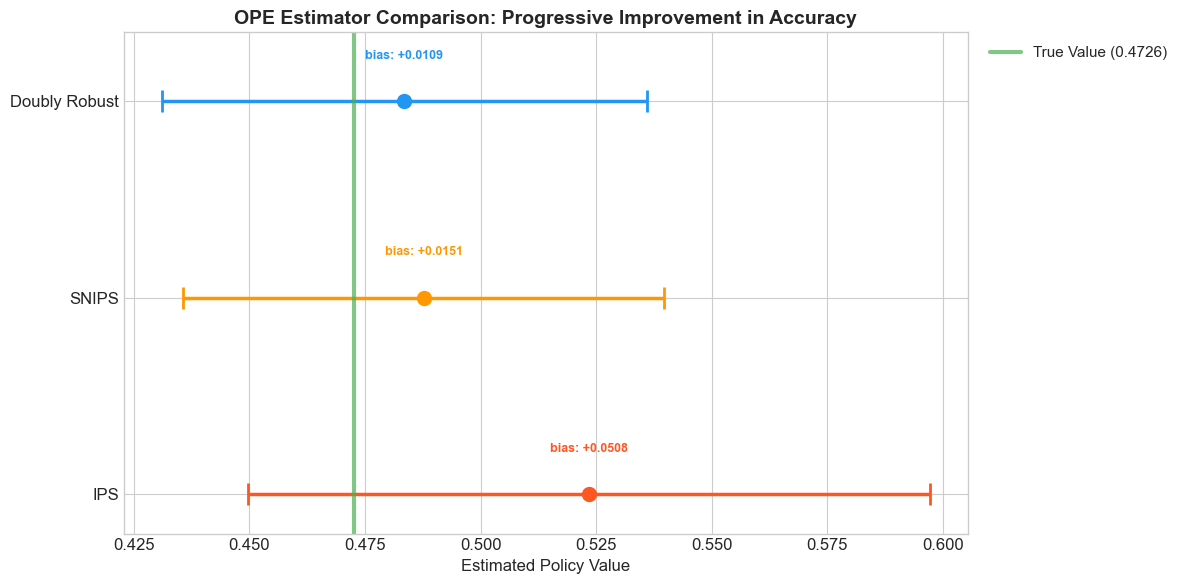

In [28]:
# Visual comparison of all estimators
fig, ax = plt.subplots(figsize=(12, 6))

method_names = list(methods.keys())
estimates = [methods[m]['estimate'] for m in method_names]
ci_lowers = [methods[m]['ci_lower'] for m in method_names]
ci_uppers = [methods[m]['ci_upper'] for m in method_names]

colors_est = ['#FF5722', '#FF9800', '#2196F3']
y_pos = range(len(method_names))

for i, (name, est, cl, cu) in enumerate(zip(method_names, estimates, ci_lowers, ci_uppers)):
    ax.errorbar(est, i, xerr=[[est - cl], [cu - est]], fmt='o', capsize=8,
                markersize=10, linewidth=2.5, color=colors_est[i], capthick=2)
    # Annotate with bias above each line
    bias = est - true_target_value
    ax.annotate(f'bias: {bias:+.4f}', xy=(est, i + 0.2), ha='center', va='bottom', 
                fontsize=9, color=colors_est[i], fontweight='bold')

ax.axvline(x=true_target_value, color='#4CAF50', linestyle='-', linewidth=3, 
           alpha=0.7, label=f'True Value ({true_target_value:.4f})')

ax.set_yticks(y_pos)
ax.set_yticklabels(method_names, fontsize=12)
ax.set_xlabel("Estimated Policy Value", fontsize=12)
ax.set_title("OPE Estimator Comparison: Progressive Improvement in Accuracy", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1.01, 1), framealpha=0.9)

ax.set_ylim(-0.2, len(method_names) - 1 + 0.35)

plt.tight_layout()
plt.show()


---

## 7. When OPE Breaks Down

Understanding failure modes is as important as implementing the methods. This section explores conditions under which off-policy evaluation produces unreliable estimates, and what practitioners can do about it.

### 7.1 The Exploration Rate Controls Everything

OPE requires that the logging policy had a nonzero probability of selecting every arm the target policy might choose. When the logging policy is too greedy (low epsilon), there's insufficient overlap, and importance weights become extreme. The visualization below shows this directly: as epsilon decreases, the arm selection becomes more concentrated, the data becomes less usable, and OPE estimates degrade.


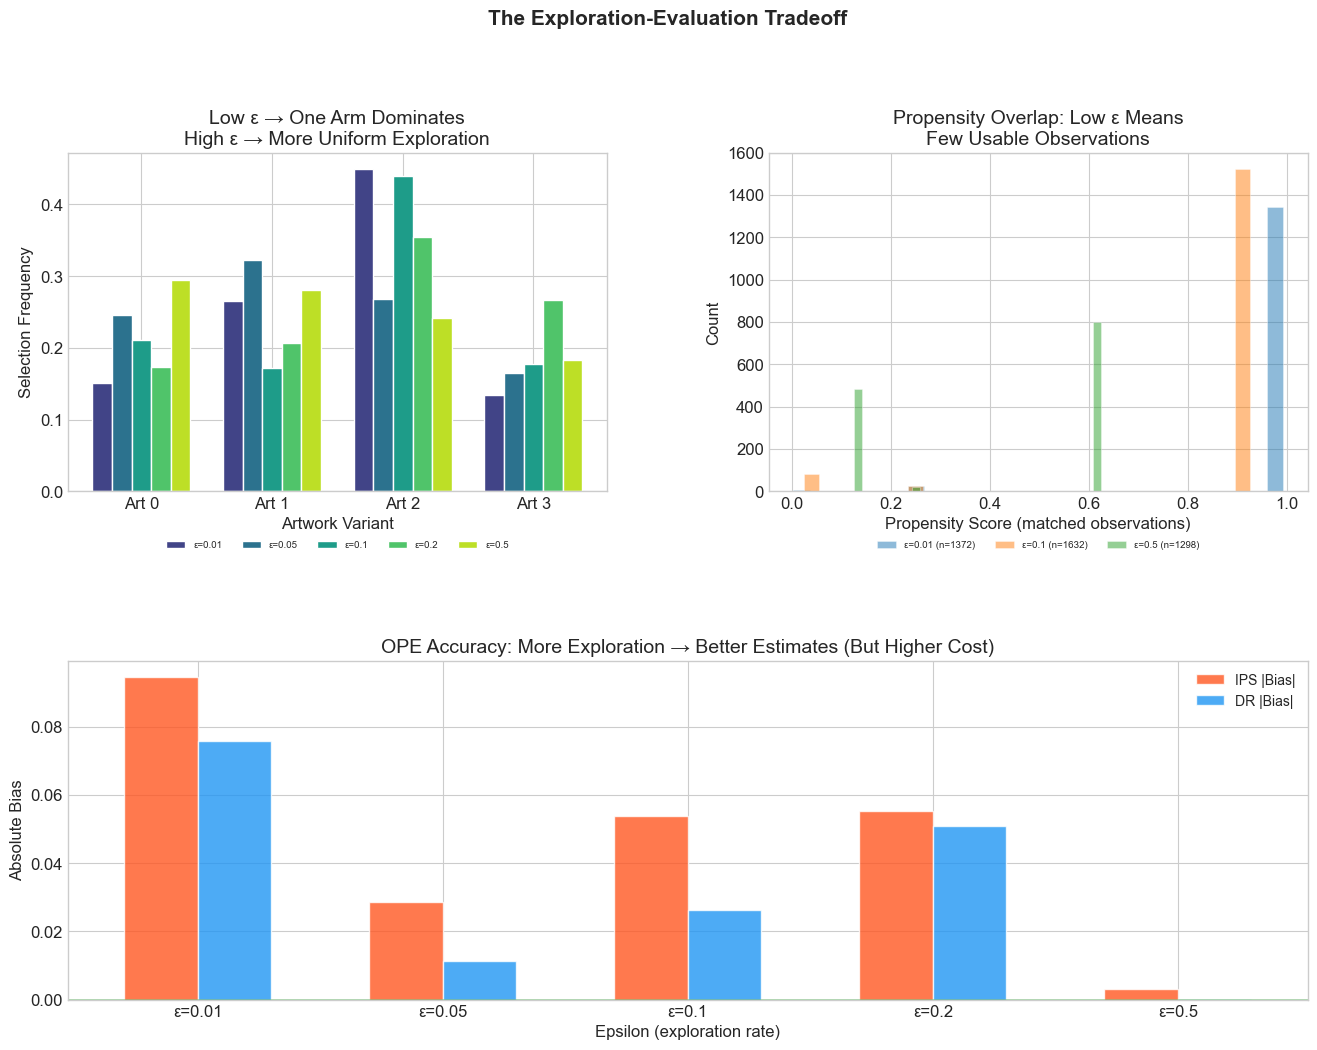

Key insight: the exploration rate of the logging policy directly determines
the quality of off-policy evaluation. This is why the Causal Science team
needs a seat at the table when setting system parameters.


In [20]:
# Epsilon sweep: effect on arm distribution and OPE quality
epsilons = [0.01, 0.05, 0.1, 0.2, 0.5]
results_by_epsilon = {}
arm_distributions = {}

for eps in epsilons:
    bandit_eps = EpsilonGreedyContextualBandit(n_arms=4, n_features=3, epsilon=eps, seed=42)
    logs_eps = run_bandit(env, bandit_eps, n_rounds=5000)
    target_arms_eps = get_target_arms(logs_eps, target_policy_simple)
    
    ips_res = ips_estimator(logs_eps, target_policy_simple, env.n_arms, target_arms=target_arms_eps)
    dr_res = doubly_robust_estimator(logs_eps, target_policy_simple, env.n_arms, target_arms=target_arms_eps)
    
    results_by_epsilon[eps] = {'ips': ips_res, 'dr': dr_res}
    arm_distributions[eps] = logs_eps['arm'].value_counts(normalize=True).sort_index()


fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(2, 2, hspace=0.5, wspace=0.3)

# Top left: arm selection distributions by epsilon
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(env.n_arms)
width = 0.15
cmap = plt.cm.viridis(np.linspace(0.2, 0.9, len(epsilons)))

for i, eps in enumerate(epsilons):
    dist = arm_distributions[eps]
    bars = ax1.bar(x + i*width, [dist.get(a, 0) for a in range(env.n_arms)], 
                   width, label=f'ε={eps}', color=cmap[i], edgecolor='white')

ax1.set_xlabel("Artwork Variant")
ax1.set_ylabel("Selection Frequency")
ax1.set_title("Low ε → One Arm Dominates\nHigh ε → More Uniform Exploration")
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels([f'Art {a}' for a in range(env.n_arms)])
ax1.legend(fontsize=7, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.12), framealpha=0.9)

# Top right: propensity score distributions
ax2 = fig.add_subplot(gs[0, 1])
for i, eps in enumerate([0.01, 0.1, 0.5]):
    bandit_tmp = EpsilonGreedyContextualBandit(n_arms=4, n_features=3, epsilon=eps, seed=42)
    logs_tmp = run_bandit(env, bandit_tmp, n_rounds=5000)
    target_arms_tmp = get_target_arms(logs_tmp, target_policy_simple)
    
    # Propensities for matched observations only
    match = (logs_tmp['arm'].values == target_arms_tmp)
    matched_props = logs_tmp.loc[match, 'propensity'].values
    
    if len(matched_props) > 0:
        ax2.hist(matched_props, bins=30, alpha=0.5, label=f'ε={eps} (n={len(matched_props)})',
                 edgecolor='white', linewidth=0.5)

ax2.set_xlabel("Propensity Score (matched observations)")
ax2.set_ylabel("Count")
ax2.set_title("Propensity Overlap: Low ε Means\nFew Usable Observations")
ax2.legend(fontsize=7, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.12), framealpha=0.9)

# Bottom: OPE accuracy by epsilon
ax3 = fig.add_subplot(gs[1, :])

ips_ests = [results_by_epsilon[e]['ips']['estimate'] for e in epsilons]
ips_ses = [results_by_epsilon[e]['ips']['se'] for e in epsilons]
dr_ests = [results_by_epsilon[e]['dr']['estimate'] for e in epsilons]
dr_ses = [results_by_epsilon[e]['dr']['se'] for e in epsilons]

x_pos = np.arange(len(epsilons))
width = 0.3

ax3.bar(x_pos - width/2, [abs(e - true_target_value) for e in ips_ests], 
        width, label='IPS |Bias|', color='#FF5722', alpha=0.8, edgecolor='white')
ax3.bar(x_pos + width/2, [abs(e - true_target_value) for e in dr_ests], 
        width, label='DR |Bias|', color='#2196F3', alpha=0.8, edgecolor='white')

ax3.set_xlabel("Epsilon (exploration rate)")
ax3.set_ylabel("Absolute Bias")
ax3.set_title("OPE Accuracy: More Exploration → Better Estimates (But Higher Cost)")
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f'ε={e}' for e in epsilons])
ax3.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax3.axhline(y=0, color='#4CAF50', linewidth=2, alpha=0.5)

plt.suptitle("The Exploration-Evaluation Tradeoff", fontsize=15, fontweight='bold', y=1.01)
plt.show()

print("Key insight: the exploration rate of the logging policy directly determines")
print("the quality of off-policy evaluation. This is why a data scientist")
print("needs a seat at the table when setting system parameters.")


### 7.2 Propensity Clipping: Trading Bias for Variance

One practical mitigation for high-variance importance weights is propensity clipping: capping the maximum importance weight at some threshold. This trades bias for variance, which is often worth it in practice.


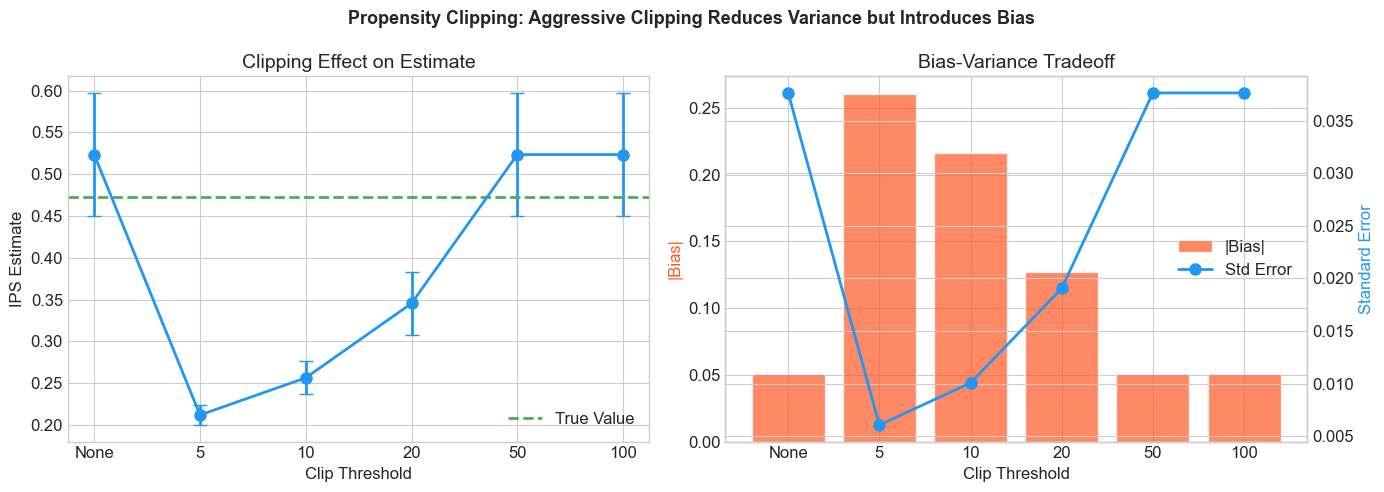

In [21]:
# Effect of clipping on IPS
clip_values = [None, 5, 10, 20, 50, 100]

clip_results = []
for clip in clip_values:
    result = ips_estimator(bandit_logs, target_policy_simple, env.n_arms, clip=clip, target_arms=target_arms)
    clip_results.append({
        'clip': clip if clip else 'None',
        'estimate': result['estimate'],
        'se': result['se'],
        'bias': result['estimate'] - true_target_value,
    })

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

clip_labels = [str(c['clip']) for c in clip_results]
ests = [c['estimate'] for c in clip_results]
ses = [c['se'] for c in clip_results]
biases = [abs(c['bias']) for c in clip_results]

# Left: estimate with CI
ax1.errorbar(range(len(clip_labels)), ests, yerr=[1.96*s for s in ses], 
             fmt='o-', capsize=5, linewidth=2, markersize=8, color='#2196F3')
ax1.axhline(y=true_target_value, color='#4CAF50', linestyle='--', linewidth=2, label='True Value')
ax1.set_xticks(range(len(clip_labels)))
ax1.set_xticklabels(clip_labels)
ax1.set_xlabel("Clip Threshold")
ax1.set_ylabel("IPS Estimate")
ax1.set_title("Clipping Effect on Estimate")
ax1.legend(loc='lower right', framealpha=0.9)

# Right: bias vs variance tradeoff
ax2.bar(range(len(clip_labels)), biases, alpha=0.7, color='#FF5722', label='|Bias|', edgecolor='white')
ax2_twin = ax2.twinx()
ax2_twin.plot(range(len(clip_labels)), ses, 'o-', color='#2196F3', linewidth=2, 
              markersize=8, label='Std Error')
ax2.set_xticks(range(len(clip_labels)))
ax2.set_xticklabels(clip_labels)
ax2.set_xlabel("Clip Threshold")
ax2.set_ylabel("|Bias|", color='#FF5722')
ax2_twin.set_ylabel("Standard Error", color='#2196F3')
ax2.set_title("Bias-Variance Tradeoff")
# Combine legends from both axes
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='center right', framealpha=0.9)

plt.suptitle("Propensity Clipping: Aggressive Clipping Reduces Variance but Introduces Bias",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 8. Key Takeaways

### A/B Testing vs. Bandits: Different Tools for Different Objectives

| Dimension | A/B Test | Multi-Armed Bandit |
|-----------|----------|-------------------|
| **Objective** | Maximize learning (causal inference) | Maximize reward (optimization) |
| **Assignment** | Random, fixed | Adaptive, policy-driven |
| **Causal validity** | Unbiased by design | Biased without correction |
| **Cost** | Serves suboptimal variants to many users | Minimal regret, but hard to evaluate |
| **When to use** | Evaluating a major change, need clean estimate | Always-on personalization, many variants |

### Off-Policy Evaluation: Bridging the Gap

When a bandit system is in production and you can't afford to run a new A/B test for every policy change, OPE lets you evaluate candidate policies from historical logs. The key requirements:

1. **Known propensity scores:** The logging policy must have recorded (or you must be able to reconstruct) the probability with which it selected each arm for each context.
2. **Sufficient overlap:** The logging policy must have explored enough that there's data for the arms the target policy would select.
3. **Appropriate estimator choice:** IPS is unbiased but high-variance. SNIPS trades small bias for lower variance. Doubly Robust is preferred when a reasonable reward model can be fitted.

### Practical Recommendations

- **Log your propensity scores.** Every production bandit system should record the probability distribution over arms at decision time. Without this, OPE is impossible.
- **Maintain minimum exploration.** Even a small epsilon in an epsilon-greedy policy preserves the ability to do off-policy evaluation later.
- **Use Doubly Robust when possible.** It provides the best of both worlds and is robust to misspecification of either the reward model or propensity scores.
- **Always validate.** When you can run an A/B test, use it to validate your OPE estimates. Build trust in the estimators before relying on them for decisions you can't verify.

---

*This analysis demonstrates the methodological foundations for causal evaluation of adaptive personalization systems. On a streaming platform, the artwork bandit makes millions of daily decisions that directly affect browse engagement and subscriber retention. Well positioned data scientists can help ensure those adaptive decisions are actually working: catching false wins, validating policy changes, and protecting the platform from optimizing on noise.*
